In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Carga de los datos en bruto
data=pd.read_csv("../Datos en bruto/Gripe/VIW_FNT.csv", sep=",") 
data

,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHERRESPVIRUS,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV
0,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-30,2017,5,2017-01-29,...,NaN,NaN,NaN,NaN,AW,201705,201705,NaN,NaN,NaN
1,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-03-06,2017,10,2017-03-05,...,NaN,NaN,NaN,NaN,AW,201710,201710,NaN,NaN,NaN
2,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-23,2017,4,2017-01-22,...,NaN,NaN,NaN,NaN,AW,201704,201704,NaN,NaN,NaN
3,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-02-27,2017,9,2017-02-26,...,NaN,NaN,NaN,NaN,AW,201709,201709,NaN,NaN,NaN
4,AMR,YR,NH,FLU_CNT_AMC,ABW,Aruba,2017-01-16,2017,3,2017-01-15,...,NaN,NaN,NaN,NaN,AW,201703,201703,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170061,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2024-10-14,2024,42,2024-10-13,...,NaN,NaN,NaN,NaN,ZW,202442,202442,NaN,NaN,NaN
170062,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2024-11-18,2024,47,2024-11-17,...,NaN,NaN,NaN,NaN,ZW,202447,202447,NaN,NaN,NaN
170063,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2024-12-23,2024,52,2024-12-22,...,NaN,NaN,NaN,NaN,ZW,202452,202452,NaN,NaN,NaN
170064,AFR,YR,SH,FLU_EST_AFR,ZWE,Zimbabwe,2025-01-27,2025,5,2025-01-26,...,NaN,NaN,NaN,NaN,ZW,202505,202505,NaN,NaN,NaN


In [3]:
# Filtrado de los registros del 2008 y años posteriores para la región de España siendo la fuente de origen de estos de 
# tipo SENTINEL
flu_ESP=data[(data.COUNTRY_AREA_TERRITORY=='Spain')&(data.ORIGIN_SOURCE=='SENTINEL')]
flu_ESP

,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHERRESPVIRUS,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV
30526,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2013-10-21,2013,43,2013-10-20,...,NaN,NaN,NaN,NaN,ES,201343,201343,1.0,1.0,1.0
30528,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2013-11-25,2013,48,2013-11-24,...,NaN,NaN,NaN,NaN,ES,201348,201348,1.0,1.0,1.0
30780,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-01-16,2017,3,2017-01-15,...,NaN,NaN,NaN,NaN,ES,201703,201703,1.0,1.0,1.0
30781,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-02-20,2017,8,2017-02-19,...,NaN,NaN,NaN,NaN,ES,201708,201708,1.0,1.0,1.0
30811,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-03-27,2017,13,2017-03-26,...,NaN,NaN,NaN,NaN,ES,201713,201713,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67505,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2023-11-06,2023,45,2023-11-05,...,NaN,NaN,NaN,NaN,ES,202345,202345,1.0,1.0,1.0
67507,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2023-12-11,2023,50,2023-12-10,...,NaN,NaN,NaN,NaN,ES,202350,202350,1.0,1.0,1.0
67511,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2025-01-06,2025,2,2025-01-05,...,NaN,NaN,NaN,NaN,ES,202502,202502,1.0,1.0,1.0
67515,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2025-02-10,2025,7,2025-02-09,...,NaN,NaN,NaN,NaN,ES,202507,202507,1.0,1.0,1.0


In [4]:
#Se modifica el valor de la fecha para que sean valores en domingos en vez de lunes
flu_ESP['Fecha']=pd.to_datetime(flu_ESP['ISO_WEEKSTARTDATE'])-timedelta(days=1)
flu_ESP

,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV,Fecha
30526,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2013-10-21,2013,43,2013-10-20,...,NaN,NaN,NaN,ES,201343,201343,1.0,1.0,1.0,2013-10-20
30528,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2013-11-25,2013,48,2013-11-24,...,NaN,NaN,NaN,ES,201348,201348,1.0,1.0,1.0,2013-11-24
30780,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-01-16,2017,3,2017-01-15,...,NaN,NaN,NaN,ES,201703,201703,1.0,1.0,1.0,2017-01-15
30781,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-02-20,2017,8,2017-02-19,...,NaN,NaN,NaN,ES,201708,201708,1.0,1.0,1.0,2017-02-19
30811,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-03-27,2017,13,2017-03-26,...,NaN,NaN,NaN,ES,201713,201713,1.0,1.0,1.0,2017-03-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67505,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2023-11-06,2023,45,2023-11-05,...,NaN,NaN,NaN,ES,202345,202345,1.0,1.0,1.0,2023-11-05
67507,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2023-12-11,2023,50,2023-12-10,...,NaN,NaN,NaN,ES,202350,202350,1.0,1.0,1.0,2023-12-10
67511,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2025-01-06,2025,2,2025-01-05,...,NaN,NaN,NaN,ES,202502,202502,1.0,1.0,1.0,2025-01-05
67515,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2025-02-10,2025,7,2025-02-09,...,NaN,NaN,NaN,ES,202507,202507,1.0,1.0,1.0,2025-02-09


In [5]:
# Para el tratamiento de los valores nulos se rellenan los nulos de las variantes de tipo A y B con ceros para posteriormente
# rellenar los nulos de todas las variantes con la suma de ambas.
flu_ESP.INF_A=flu_ESP.INF_A.fillna(0)
flu_ESP.INF_B=flu_ESP.INF_B.fillna(0)
flu_ESP.INF_ALL=flu_ESP.INF_ALL.fillna(flu_ESP.INF_A+flu_ESP.INF_B)
flu_ESP

,WHOREGION,FLUSEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV,Fecha
30526,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2013-10-21,2013,43,2013-10-20,...,NaN,NaN,NaN,ES,201343,201343,1.0,1.0,1.0,2013-10-20
30528,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2013-11-25,2013,48,2013-11-24,...,NaN,NaN,NaN,ES,201348,201348,1.0,1.0,1.0,2013-11-24
30780,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-01-16,2017,3,2017-01-15,...,NaN,NaN,NaN,ES,201703,201703,1.0,1.0,1.0,2017-01-15
30781,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-02-20,2017,8,2017-02-19,...,NaN,NaN,NaN,ES,201708,201708,1.0,1.0,1.0,2017-02-19
30811,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2017-03-27,2017,13,2017-03-26,...,NaN,NaN,NaN,ES,201713,201713,1.0,1.0,1.0,2017-03-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67505,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2023-11-06,2023,45,2023-11-05,...,NaN,NaN,NaN,ES,202345,202345,1.0,1.0,1.0,2023-11-05
67507,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2023-12-11,2023,50,2023-12-10,...,NaN,NaN,NaN,ES,202350,202350,1.0,1.0,1.0,2023-12-10
67511,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2025-01-06,2025,2,2025-01-05,...,NaN,NaN,NaN,ES,202502,202502,1.0,1.0,1.0,2025-01-05
67515,EUR,NH,NH,FLU_SW_EUR,ESP,Spain,2025-02-10,2025,7,2025-02-09,...,NaN,NaN,NaN,ES,202507,202507,1.0,1.0,1.0,2025-02-09


In [6]:
#Finalmente, nos quedamos con las variables INF_ALL y Fecha
flu_ESP=flu_ESP.loc[:,['INF_ALL','Fecha']]
flu_ESP.set_index('Fecha',inplace=True)
flu_ESP=flu_ESP.sort_index()
flu_ESP

,INF_ALL
Fecha,
2013-09-29,1.0
2013-10-06,1.0
2013-10-13,0.0
2013-10-20,1.0
2013-10-27,0.0
...,...
2025-02-23,166.0
2025-03-02,76.0
2025-03-09,117.0


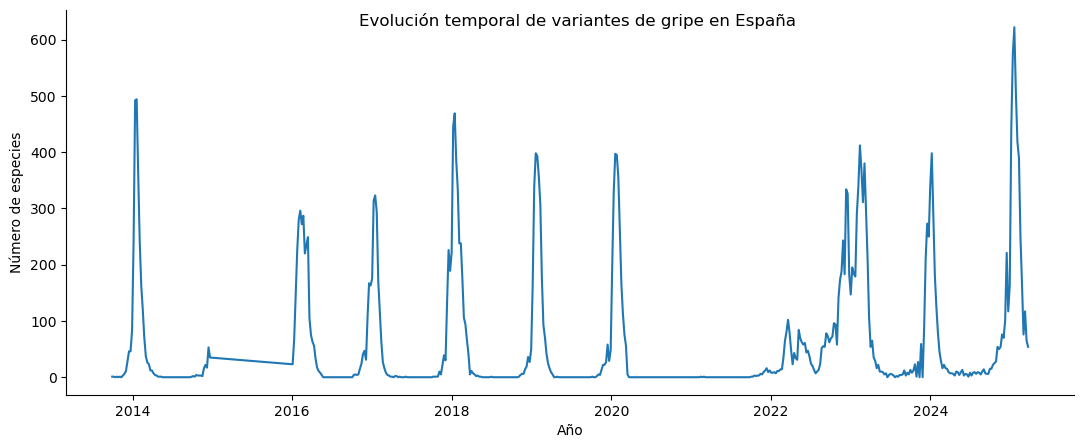

In [25]:
plt.figure(figsize=(13,5))
ax=sns.lineplot(data=flu_ESP,x=flu_ESP.index,y=flu_ESP.INF_ALL)
plt.text(datetime(2016, 11, 1),625, 'Evolución temporal de variantes de gripe en España', fontsize=12)
plt.xlabel('Año')
plt.ylabel('Número de especies')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [8]:
#Exportamos los datos relativos a la gripe en España
flu_ESP.to_csv('flu_esp_indexado.csv',index=True,encoding='utf-8')